In [1]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


=== BASIC INFO ===
Dataset shape: (12330, 18)

Column names and data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

=== MISSING VALUES ===
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues              

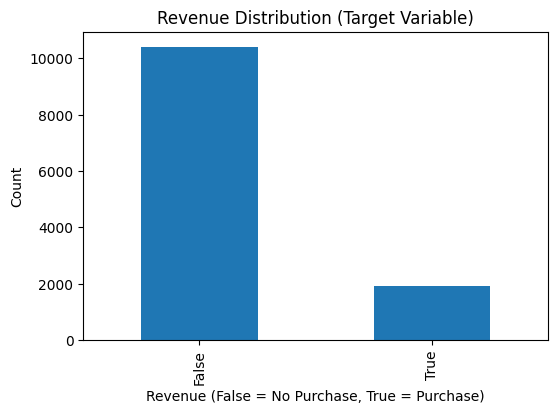

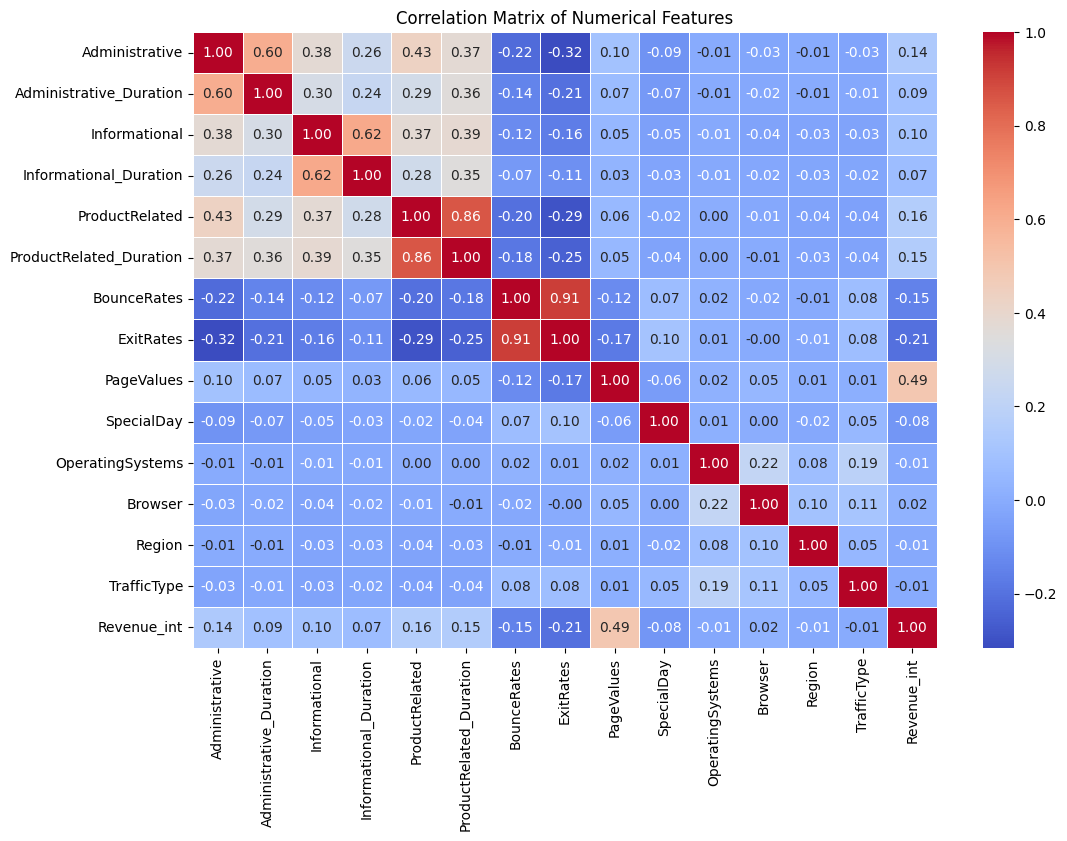

In [3]:
# Install any missing libraries (Colab has most already)
!pip install pandas numpy matplotlib seaborn -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')

# 1. Basic Info
print("=== BASIC INFO ===")
print(f"Dataset shape: {df.shape}")
print("\nColumn names and data types:")
print(df.dtypes)

# 2. Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# 3. Target variable distribution
print("\n=== TARGET DISTRIBUTION (Revenue) ===")
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True) * 100)

# 4. Summary statistics for numerical columns
print("\n=== NUMERICAL SUMMARY ===")
print(df.describe())

# 5. Check categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {categorical_cols.tolist()}")
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")
    print(f"{col} value counts:")
    print(df[col].value_counts())

# 6. Visualize the target distribution
plt.figure(figsize=(6, 4))
df['Revenue'].value_counts().plot(kind='bar')
plt.title('Revenue Distribution (Target Variable)')
plt.xlabel('Revenue (False = No Purchase, True = Purchase)')
plt.ylabel('Count')
plt.show()

# 7. Basic correlation of numerical features with target
# Convert boolean Revenue to int for correlation
df_corr = df.copy()
df_corr['Revenue_int'] = df_corr['Revenue'].astype(int)

# Select numerical columns for correlation (excluding object types)
numerical_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [4]:
# Additional Exploration for Business Understanding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('online_shoppers_intention.csv')

print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

# 1. Class Imbalance
purchase_pct = df['Revenue'].mean() * 100
print(f"1. CLASS IMBALANCE:")
print(f"   - Purchases: {df['Revenue'].sum():,} sessions ({purchase_pct:.1f}%)")
print(f"   - No Purchases: {(~df['Revenue']).sum():,} sessions ({100-purchase_pct:.1f}%)")
print(f"   ⚠️ This is HIGHLY imbalanced - we need special handling!\n")

# 2. Feature Types
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target from numerical list
if 'Revenue' in num_cols:
    num_cols.remove('Revenue')

print(f"2. FEATURE SUMMARY:")
print(f"   - Categorical features: {len(cat_cols)} - {cat_cols}")
print(f"   - Numerical features: {len(num_cols)} - {num_cols[:8]} (showing first 8)\n")

# 3. Check for ANY features that would cause data leakage
leakage_features = ['ExitRates', 'BounceRates', 'PageValues']
print(f"3. POTENTIAL DATA LEAKAGE FEATURES:")
for feat in leakage_features:
    if feat in df.columns:
        print(f"   ⚠️ WARNING: '{feat}' is in the dataset - CANNOT use for early prediction")
print(f"   💡 We'll need to decide what to do with these!\n")

# 4. Data Quality
missing = df.isnull().sum()
print(f"4. DATA QUALITY:")
if missing.sum() == 0:
    print(f"   ✅ No missing values - clean dataset!")
else:
    print(f"   ⚠️ Missing values found:\n{missing[missing>0]}")

# 5. PageValues distribution (to understand why it's problematic)
if 'PageValues' in df.columns:
    print(f"\n5. PAGeVALUE ANALYSIS:")
    print(f"   - Has PageValues = 0 for {((df['PageValues'] == 0).sum() / len(df) * 100):.1f}% of sessions")
    print(f"   - PageValues max: {df['PageValues'].max():.2f}")
    print(f"   - PageValues mean (excluding zeros): {df[df['PageValues']>0]['PageValues'].mean():.2f}")
    print(f"   ⚠️ This is the total value of pages visited - ONLY available at session end!")

KEY FINDINGS SUMMARY
1. CLASS IMBALANCE:
   - Purchases: 1,908 sessions (15.5%)
   - No Purchases: 10,422 sessions (84.5%)
   ⚠️ This is HIGHLY imbalanced - we need special handling!

2. FEATURE SUMMARY:
   - Categorical features: 2 - ['Month', 'VisitorType']
   - Numerical features: 14 - ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates'] (showing first 8)

3. POTENTIAL DATA LEAKAGE FEATURES:
   ⚠️ WARNING: 'ExitRates' is in the dataset - CANNOT use for early prediction
   ⚠️ WARNING: 'BounceRates' is in the dataset - CANNOT use for early prediction
   ⚠️ WARNING: 'PageValues' is in the dataset - CANNOT use for early prediction
   💡 We'll need to decide what to do with these!

4. DATA QUALITY:
   ✅ No missing values - clean dataset!

5. PAGeVALUE ANALYSIS:
   - Has PageValues = 0 for 77.9% of sessions
   - PageValues max: 361.76
   - PageValues mean (excluding zeros): 26.60
  

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('online_shoppers_intention.csv')

print("="*70)
print("DATA PREPARATION FOR EARLY-SESSION PREDICTION")
print("="*70)

# 1. Define features to drop (not available in early session)
drop_features = [
    'ExitRates',
    'BounceRates',
    'PageValues',
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'SpecialDay'  # Not reliably real-time
]

# 2. Create X and y
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"\nOriginal features: {X.shape[1]}")

# 3. Drop problematic features
X_early = X.drop(columns=drop_features, errors='ignore')

print(f"Features after dropping problematic ones: {X_early.shape[1]}")

# 4. Identify feature types
cat_cols = X_early.select_dtypes(include=['object']).columns.tolist()
num_cols = X_early.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nFeature breakdown:")
print(f"  - Categorical features: {len(cat_cols)} - {cat_cols}")
print(f"  - Numerical features: {len(num_cols)} - {num_cols}")

# 5. Check for any remaining issues
print(f"\nChecking data types:")
print(X_early.dtypes)

# 6. Split data (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_early, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nData split:")
print(f"  - Training set: {X_train.shape[0]} samples")
print(f"  - Test set: {X_test.shape[0]} samples")
print(f"  - Training class distribution:")
print(f"    Positive (purchase): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"    Negative (no purchase): {(~y_train).sum()} ({100-y_train.mean()*100:.1f}%)")

# 7. Create preprocessing pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Test the preprocessor
X_train_preprocessed = preprocessor.fit_transform(X_train)
print(f"\nPreprocessed training data shape: {X_train_preprocessed.shape}")

# 8. Preview of transformed data
print(f"\nSample of preprocessed data (first 5 rows, first 10 columns):")
print(pd.DataFrame(X_train_preprocessed[:5, :10]).round(2))

DATA PREPARATION FOR EARLY-SESSION PREDICTION

Original features: 17
Features after dropping problematic ones: 10

Feature breakdown:
  - Categorical features: 2 - ['Month', 'VisitorType']
  - Numerical features: 7 - ['Administrative', 'Informational', 'ProductRelated', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Checking data types:
Administrative       int64
Informational        int64
ProductRelated       int64
Month               object
OperatingSystems     int64
Browser              int64
Region               int64
TrafficType          int64
VisitorType         object
Weekend               bool
dtype: object

Data split:
  - Training set: 9864 samples
  - Test set: 2466 samples
  - Training class distribution:
    Positive (purchase): 1526 (15.5%)
    Negative (no purchase): 8338 (84.5%)

Preprocessed training data shape: (9864, 18)

Sample of preprocessed data (first 5 rows, first 10 columns):
      0    1     2     3     4     5     6    7    8    9
0  1.71 -0.4  0.0

BASELINE MODEL EVALUATION

DUMMY CLASSIFIER (Most Frequent):
              precision    recall  f1-score   support

 No Purchase       0.85      1.00      0.92      2084
    Purchase       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466

ROC-AUC: 0.500

LOGISTIC REGRESSION (With Class Weights):
              precision    recall  f1-score   support

 No Purchase       0.91      0.66      0.76      2084
    Purchase       0.26      0.65      0.37       382

    accuracy                           0.66      2466
   macro avg       0.58      0.65      0.57      2466
weighted avg       0.81      0.66      0.70      2466

ROC-AUC: 0.714
PR-AUC: 0.294


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


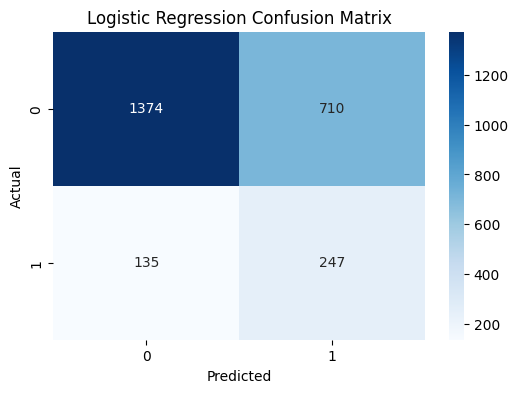

In [6]:
# Build a simple baseline model (Logistic Regression)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Create pipeline
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

print("="*70)
print("BASELINE MODEL EVALUATION")
print("="*70)

# Baseline
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

# Logistic Regression
logreg_pipeline.fit(X_train, y_train)
logreg_pred = logreg_pipeline.predict(X_test)
logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# Compare
print("\nDUMMY CLASSIFIER (Most Frequent):")
print(classification_report(y_test, baseline_pred, target_names=['No Purchase', 'Purchase']))
print(f"ROC-AUC: {roc_auc_score(y_test, baseline_pipeline.predict_proba(X_test)[:, 1]):.3f}")

print("\nLOGISTIC REGRESSION (With Class Weights):")
print(classification_report(y_test, logreg_pred, target_names=['No Purchase', 'Purchase']))
print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, logreg_proba):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, logreg_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

DATA PREPROCESSING
Categorical columns: ['Month', 'VisitorType']
Numerical columns: ['Administrative', 'Informational', 'ProductRelated', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Processed data shape: (9864, 18)
Total features: 18

DATA VERIFICATION
X_train_processed shape: (9864, 18)
X_test_processed shape: (2466, 18)
y_train shape: (9864,)
y_test shape: (2466,)

Training class distribution:
  Positive (purchase): 1526 (15.5%)
  Negative (no purchase): 8338 (84.5%)

MODEL EVALUATION

Training Logistic Regression...
Cross-Validation F1: 0.3518 (±0.0145)
Cross-Validation AUC: 0.6955 (±0.0184)
Test Set Metrics:
  - Accuracy: 0.6573
  - Precision: 0.2581
  - Recall: 0.6466
  - F1-Score: 0.3689
  - ROC-AUC: 0.7139
  - PR-AUC: 0.2943

Training Random Forest...
Cross-Validation F1: 0.1725 (±0.0149)
Cross-Validation AUC: 0.7187 (±0.0128)
Test Set Metrics:
  - Accuracy: 0.8329
  - Precision: 0.3929
  - Recall: 0.1440
  - F1-Score: 0.2107
  - ROC-AUC: 0.7157
  - PR-AUC: 0.2942



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:14:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:14:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:14:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:14:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:

Cross-Validation F1: 0.3516 (±0.0136)
Cross-Validation AUC: 0.7133 (±0.0068)
Test Set Metrics:
  - Accuracy: 0.7032
  - Precision: 0.2622
  - Recall: 0.5052
  - F1-Score: 0.3453
  - ROC-AUC: 0.7059
  - PR-AUC: 0.3036

MODEL COMPARISON SUMMARY
              Model  F1-Score  Precision   Recall  ROC-AUC   PR-AUC  CV F1 (mean)
Logistic Regression  0.368932   0.258098 0.646597 0.713938 0.294335      0.351822
      Random Forest  0.210728   0.392857 0.143979 0.715664 0.294193      0.172480
            XGBoost  0.345259   0.262228 0.505236 0.705877 0.303633      0.351584

🏆 BEST MODEL: Logistic Regression
   F1-Score: 0.3689
   PR-AUC: 0.2943


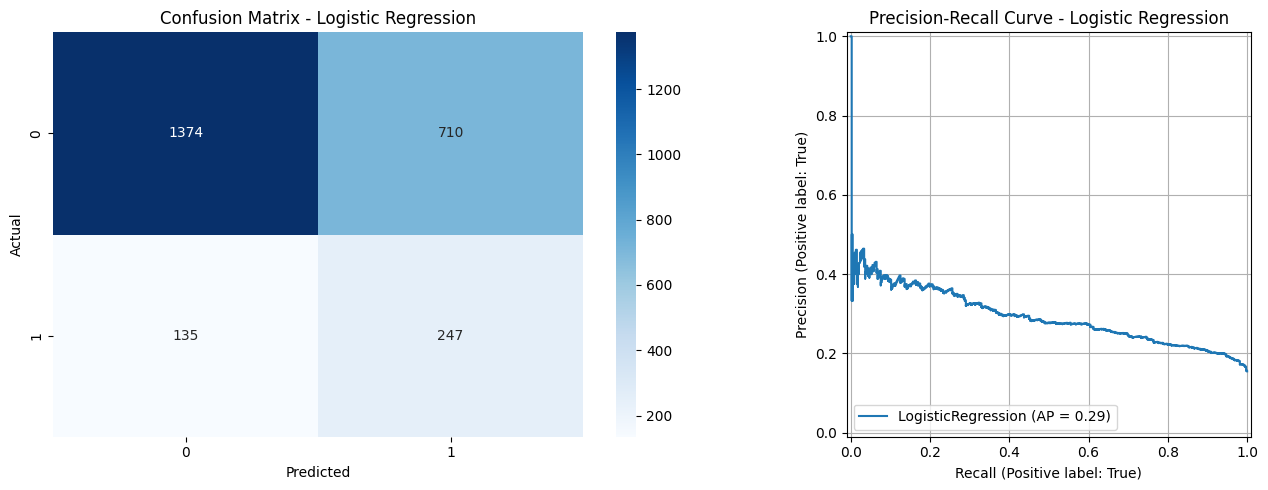


TOP 10 FEATURES - Logistic Regression
                      Feature  Importance
                    Month_Feb    2.024289
VisitorType_Returning_Visitor    0.870554
                   Month_June    0.507637
                    Month_Mar    0.445275
                    Month_Nov    0.390439
                    Month_May    0.381930
            VisitorType_Other    0.352408
                    Month_Dec    0.317910
                    Month_Oct    0.313031
               ProductRelated    0.270059


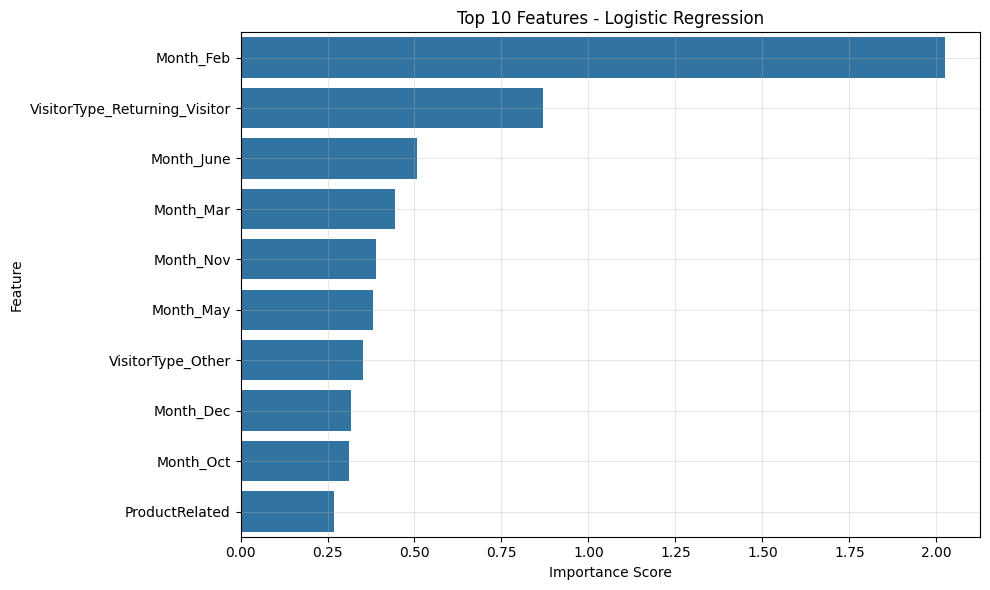


THRESHOLD OPTIMIZATION
Best Threshold: 0.5240
Best F1-Score at this threshold: 0.3772
  - Precision at this threshold: 0.2757
  - Recall at this threshold: 0.5969


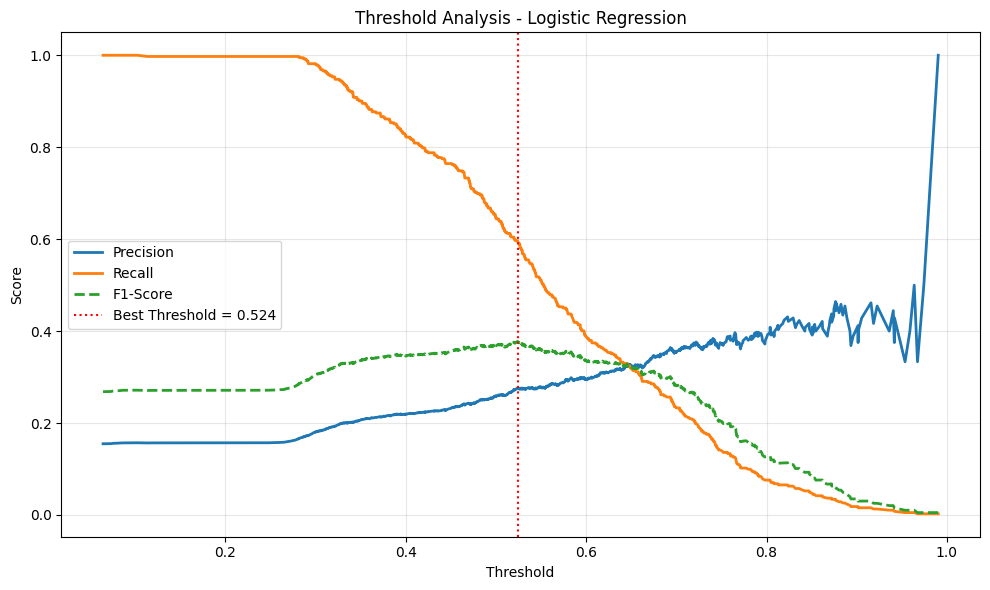


THRESHOLD BUSINESS JUSTIFICATION
Threshold: 0.524
At this threshold:
  - 27.6% of predicted purchases are correct (Precision)
  - We capture 59.7% of actual purchases (Recall)
  - F1-Score: 0.377

Alternative thresholds to consider:
  - Threshold 0.3: F1=0.305, Precision=0.181, Recall=0.982
  - Threshold 0.4: F1=0.347, Precision=0.219, Recall=0.825
  - Threshold 0.5: F1=0.369, Precision=0.258, Recall=0.647
  - Threshold 0.6: F1=0.335, Precision=0.295, Recall=0.387
  - Threshold 0.7: F1=0.282, Precision=0.357, Recall=0.233

MODEL EVALUATION COMPLETE!


In [9]:
# ============================================================
# CODE: BUILD AND EVALUATE MODELS
# ============================================================

# Step 1: Import all necessary libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("="*60)
print("DATA PREPROCESSING")
print("="*60)
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Step 3: Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Step 4: Apply preprocessing to training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for interpretation
feature_names = (numerical_cols +
                 preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist())

print(f"\nProcessed data shape: {X_train_processed.shape}")
print(f"Total features: {len(feature_names)}")

# Step 5: Verify your data
print("\n" + "="*60)
print("DATA VERIFICATION")
print("="*60)
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nTraining class distribution:")
print(f"  Positive (purchase): {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  Negative (no purchase): {len(y_train)-sum(y_train)} ({(len(y_train)-sum(y_train))/len(y_train)*100:.1f}%)")

# Step 6: Define models with class imbalance handling
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# Step 7: Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Step 8: Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc')

    # Train on full training set
    model.fit(X_train_processed, y_train)

    # Predictions
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    # Store results
    results[name] = {
        'model': model,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std': cv_auc.std(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Print results
    print(f"Cross-Validation F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"Cross-Validation AUC: {cv_auc.mean():.4f} (±{cv_auc.std():.4f})")
    print(f"Test Set Metrics:")
    print(f"  - Accuracy: {accuracy:.4f}")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall: {recall:.4f}")
    print(f"  - F1-Score: {f1:.4f}")
    print(f"  - ROC-AUC: {roc_auc:.4f}")
    print(f"  - PR-AUC: {pr_auc:.4f}")

# Step 9: Results comparison table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'F1-Score': [results[m]['f1'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'PR-AUC': [results[m]['pr_auc'] for m in results],
    'CV F1 (mean)': [results[m]['cv_f1_mean'] for m in results]
})

print(comparison_df.to_string(index=False))

# Step 10: Best model selection
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']
best_proba = results[best_model_name]['y_pred_proba']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[comparison_df['Model'] == best_model_name, 'F1-Score'].values[0]:.4f}")
print(f"   PR-AUC: {comparison_df.loc[comparison_df['Model'] == best_model_name, 'PR-AUC'].values[0]:.4f}")

# Step 11: Confusion Matrix for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# PR Curve
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(best_model, X_test_processed, y_test, ax=axes[1])
axes[1].set_title(f'Precision-Recall Curve - {best_model_name}')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Step 12: Feature importance for best model
if best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_[0])
elif best_model_name in ['Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
else:
    importances = None

if importances is not None:
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"\n{'='*60}")
    print(f"TOP 10 FEATURES - {best_model_name}")
    print(f"{'='*60}")
    print(importance_df.head(10).to_string(index=False))

    # Plot top 10 features
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = importance_df.head(10)
    sns.barplot(data=top_features, x='Importance', y='Feature', ax=ax)
    ax.set_title(f'Top 10 Features - {best_model_name}')
    ax.set_xlabel('Importance Score')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Step 13: Threshold optimization
from sklearn.metrics import precision_recall_curve

y_proba = results[best_model_name]['y_pred_proba']

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n{'='*60}")
print("THRESHOLD OPTIMIZATION")
print(f"{'='*60}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1-Score at this threshold: {f1_scores[best_idx]:.4f}")
print(f"  - Precision at this threshold: {precisions[best_idx]:.4f}")
print(f"  - Recall at this threshold: {recalls[best_idx]:.4f}")

# Plot precision-recall vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
ax.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
ax.plot(thresholds, f1_scores, label='F1-Score', linewidth=2, linestyle='--')
ax.axvline(x=best_threshold, color='red', linestyle=':', label=f'Best Threshold = {best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Analysis - {best_model_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 14: Business justification for threshold choice
print(f"\n{'='*60}")
print("THRESHOLD BUSINESS JUSTIFICATION")
print(f"{'='*60}")
print(f"Threshold: {best_threshold:.3f}")
print(f"At this threshold:")
print(f"  - {precisions[best_idx]*100:.1f}% of predicted purchases are correct (Precision)")
print(f"  - We capture {recalls[best_idx]*100:.1f}% of actual purchases (Recall)")
print(f"  - F1-Score: {f1_scores[best_idx]:.3f}")

print(f"\nAlternative thresholds to consider:")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_alt = (y_proba >= thresh).astype(int)
    f1_alt = f1_score(y_test, y_pred_alt)
    prec_alt = precision_score(y_test, y_pred_alt)
    rec_alt = recall_score(y_test, y_pred_alt)
    print(f"  - Threshold {thresh:.1f}: F1={f1_alt:.3f}, Precision={prec_alt:.3f}, Recall={rec_alt:.3f}")

print("\n" + "="*60)
print("MODEL EVALUATION COMPLETE!")
print("="*60)

In [12]:
# ============================================================
# HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
# ============================================================
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]
}

# Setup grid search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_processed, y_train)

# Best parameters
print("="*60)
print("BEST HYPERPARAMETERS")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_processed)
y_pred_proba_best = best_lr.predict_proba(X_test_processed)[:, 1]

# Calculate metrics
f1_best = f1_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)

print(f"\nTest Set Performance with Best Parameters:")
print(f"  - F1-Score: {f1_best:.4f}")
print(f"  - Precision: {precision_best:.4f}")
print(f"  - Recall: {recall_best:.4f}")

# Compare with default
print(f"\nImprovement over default:")
print(f"  - F1: {f1_best - 0.3689:.4f} ({(f1_best/0.3689 - 1)*100:.1f}%)")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
BEST HYPERPARAMETERS
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV F1-Score: 0.3534

Test Set Performance with Best Parameters:
  - F1-Score: 0.3689
  - Precision: 0.2593
  - Recall: 0.6387

Improvement over default:
  - F1: -0.0000 (-0.0%)
